In [3]:
# import packages
import pandas as pd
import numpy as np

import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer

print("✓ Packages imported")

Import success


In [5]:
nltk.download('stopwords') #common words to remove
nltk.download('punkt') #tokenizer
nltk.download('wordnet') #for lemmatization
nltk.download('omw-1.4') #open multilingual wordnet

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jadelynminneke/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/jadelynminneke/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/jadelynminneke/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/jadelynminneke/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# Text Dataset
WELFake Dataset from [kaggle](https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification)

Dataset contains four columns: 
- Serial number (starting from 0)
-  Title (about the text news heading)
-  Text (about the news content)
-  Label (0 = fake and 1 = real)

In [4]:
df = pd.read_csv('/Users/jadelynminneke/Desktop/NTU/Y2S2/IS460 ML/Project/Datasets/Dataset_Text/WELFake_Dataset.csv')

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"Total articles: {len(df)}")

Dataset loaded successfully!
Dataset shape: (72134, 4)
Total articles: 72134


In [5]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [6]:
# Drop the index column carried over from the original csv
df = df.drop(columns=["Unnamed: 0"])

In [7]:
# Check for missing values
print("\nMissing Values:")
missing_counts = df.isnull().sum()
print(missing_counts)

# Check for missing values
print("\nWhite Spaces:")
whitespace_counts = df.apply(
    lambda col: col.astype(str).str.strip().eq("").sum()
)
print(whitespace_counts)

# Check for duplicates
duplicate_count = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicate_count}")

# Check distribution
print("\nLabel Distribution")
print(f"Fake news (0): {(df['label'] == 0).sum()} ({(df['label'] == 0).sum()/len(df)*100:.2f}%)")
print(f"Real news (1): {(df['label'] == 1).sum()} ({(df['label'] == 1).sum()/len(df)*100:.2f}%)")


Missing Values:
title    558
text      39
label      0
dtype: int64

White Spaces:
title      0
text     744
label      0
dtype: int64

Duplicate Rows: 8456

Label Distribution
Fake news (0): 35028 (48.56%)
Real news (1): 37106 (51.44%)


In [8]:
# Drop rows where title or text is null
df = df.dropna(subset=["title", "text"])

# Drop rows where text is whitespace-only
df = df[df["text"].str.strip() != ""]

# Drop duplicates
df = df.drop_duplicates(subset=["title", "text"])

df = df.reset_index(drop=True)
df.shape

(62592, 3)

In [9]:
# Check updated distribution
print("\nUpdated Label Distribution")
print(f"Fake news (0): {(df['label'] == 0).sum()} ({(df['label'] == 0).sum()/len(df)*100:.2f}%)")
print(f"Real news (1): {(df['label'] == 1).sum()} ({(df['label'] == 1).sum()/len(df)*100:.2f}%)")


Updated Label Distribution
Fake news (0): 34790 (55.58%)
Real news (1): 27802 (44.42%)


In [11]:
# Text preprocessing function
def clean_text(text, remove_stopwords_flag=True, lemmatize=True):
    text = str(text).lower() # Convert to string and lowercase
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'<.*?>', '', text) # Remove HTML
    text = re.sub(r'[^a-zA-Z\s]', ' ', text) # Remove special characters and digits
    text = ' '.join(text.split()) # Remove extra whitespaces

    # Remove stopwords
    if remove_stopwords_flag:
        stop_words = set(stopwords.words('english'))
        text = ' '.join([word for word in text.split() if word not in stop_words])
    
    # Lemmatization
    if lemmatize:
        lemmatizer = WordNetLemmatizer()
        text = ' '.join([lemmatizer.lemmatize(word) for word in text.split()])

    return text

df["title_cleaned"] = df["title"].apply(clean_text)
df["text_cleaned"] = df["text"].apply(clean_text)

df.head()

,title,text,label,title_cleaned,text_cleaned
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,law enforcement high alert following threat co...,comment expected barack obama member fyf fukyo...
1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,unbelievable obama attorney general say charlo...,demonstrator gathered last night exercising co...
2,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,bobby jindal raised hindu us story christian c...,dozen politically active pastor came private d...
3,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,satan russia unvelis image terrifying new supe...,r sarmat missile dubbed satan replace s fly mi...
4,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,time christian group sue amazon splc designati...,say one time someone sued southern poverty law...


In [12]:
# Tokenize
df["title_cleaned"] = df["title_cleaned"].apply(word_tokenize)
df["text_cleaned"] = df["text_cleaned"].apply(word_tokenize)
df.head()

,title,text,label,title_cleaned,text_cleaned
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,"[law, enforcement, high, alert, following, thr...","[comment, expected, barack, obama, member, fyf..."
1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,"[unbelievable, obama, attorney, general, say, ...","[demonstrator, gathered, last, night, exercisi..."
2,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"[bobby, jindal, raised, hindu, us, story, chri...","[dozen, politically, active, pastor, came, pri..."
3,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,"[satan, russia, unvelis, image, terrifying, ne...","[r, sarmat, missile, dubbed, satan, replace, s..."
4,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,"[time, christian, group, sue, amazon, splc, de...","[say, one, time, someone, sued, southern, pove..."


In [13]:
df.to_csv("text_data.csv", index=False)

# Image Dataset

CASIA v2.0 from [GitHub](https://github.com/namtpham/casia2groundtruth/blob/master/README.md)

Contains: Authentic images (Au) + Tampered images (Tp) + Ground truth masks

In [52]:
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt

print("✓ Packages imported")

✓ Packages imported


In [28]:
# Dataset paths using pathlib
BASE_DIR = Path('/Users/jadelynminneke/Desktop/NTU/Y2S2/IS460 ML/Project/Datasets/Dataset_Images/CASIA2.0_revised')
AUTHENTIC_DIR = BASE_DIR / 'Au'
TAMPERED_DIR = BASE_DIR / 'Tp'

# .txt list files
AU_LIST_FILE = Path('/Users/jadelynminneke/Desktop/NTU/Y2S2/IS460 ML/Project/Datasets/Dataset_Images/CASIA2.0_revised/au_list.txt')
TP_LIST_FILE = Path('/Users/jadelynminneke/Desktop/NTU/Y2S2/IS460 ML/Project/Datasets/Dataset_Images/CASIA2.0_revised/tp_list.txt')

print("Dataset Paths:")
print(f"  Base: {BASE_DIR}")
print(f"  Authentic folder: {AUTHENTIC_DIR}")
print(f"  Tampered folder: {TAMPERED_DIR}")
print(f"  Au list file: {AU_LIST_FILE}")
print(f"  Tp list file: {TP_LIST_FILE}")

# Check if paths exist
print("\nPath Check:")
print(f"  Base dir exists: {BASE_DIR.exists()}")
print(f"  Au folder exists: {AUTHENTIC_DIR.exists()}")
print(f"  Tp folder exists: {TAMPERED_DIR.exists()}")
print(f"  Au list exists: {AU_LIST_FILE.exists()}")
print(f"  Tp list exists: {TP_LIST_FILE.exists()}")

Dataset Paths:
  Base: /Users/jadelynminneke/Desktop/NTU/Y2S2/IS460 ML/Project/Datasets/Dataset_Images/CASIA2.0_revised
  Authentic folder: /Users/jadelynminneke/Desktop/NTU/Y2S2/IS460 ML/Project/Datasets/Dataset_Images/CASIA2.0_revised/Au
  Tampered folder: /Users/jadelynminneke/Desktop/NTU/Y2S2/IS460 ML/Project/Datasets/Dataset_Images/CASIA2.0_revised/Tp
  Au list file: /Users/jadelynminneke/Desktop/NTU/Y2S2/IS460 ML/Project/Datasets/Dataset_Images/CASIA2.0_revised/au_list.txt
  Tp list file: /Users/jadelynminneke/Desktop/NTU/Y2S2/IS460 ML/Project/Datasets/Dataset_Images/CASIA2.0_revised/tp_list.txt

Path Check:
  Base dir exists: True
  Au folder exists: True
  Tp folder exists: True
  Au list exists: True
  Tp list exists: True


In [29]:
# Read authentic image names from txt file
au_names = AU_LIST_FILE.read_text().strip().split('\n')
au_names = [name.strip() for name in au_names if name.strip()]

# Read tampered image names from txt file
tp_names = TP_LIST_FILE.read_text().strip().split('\n')
tp_names = [name.strip() for name in tp_names if name.strip()]

print(f"\nLoaded from txt files:")
print(f"  Authentic images: {len(au_names)}")
print(f"  Tampered images: {len(tp_names)}")
print(f"  Total: {len(au_names) + len(tp_names)}")

# Show sample names
print(f"\nSample authentic names:")
for name in au_names[:3]:
    print(f"  {name}")
    
print(f"\nSample tampered names:")
for name in tp_names[:3]:
    print(f"  {name}")


Loaded from txt files:
  Authentic images: 7491
  Tampered images: 5123
  Total: 12614

Sample authentic names:
  Au_ani_00001.jpg
  Au_ani_00002.jpg
  Au_ani_00003.jpg

Sample tampered names:
  Tp_D_CND_M_N_ani00018_sec00096_00138.tif
  Tp_D_CND_M_N_art00076_art00077_10289.tif
  Tp_D_CND_M_N_art00077_art00076_10290.tif


In [26]:
# Function to get file extension
def get_extension(filename):
    return Path(filename).suffix.lower()

# Count formats in authentic images
au_formats = Counter([get_extension(name) for name in au_names])
print("\nAuthentic Images - File Formats:")
for fmt, count in au_formats.items():
    print(f"  {fmt}: {count} files ({count/len(au_names)*100:.2f}%)")

# Count formats in tampered images
tp_formats = Counter([get_extension(name) for name in tp_names])
print("\nTampered Images - File Formats:")
for fmt, count in tp_formats.items():
    print(f"  {fmt}: {count} files ({count/len(tp_names)*100:.2f}%)")

# All formats combined
all_formats = Counter(list(au_formats.elements()) + list(tp_formats.elements()))
print("\nAll Images - File Formats:")
for fmt, count in all_formats.items():
    print(f"  {fmt}: {count} files")


Authentic Images - File Formats:
  .jpg: 7437 files (99.28%)
  .bmp: 54 files (0.72%)

Tampered Images - File Formats:
  .tif: 3059 files (59.71%)
  .jpg: 2064 files (40.29%)

All Images - File Formats:
  .jpg: 9501 files
  .bmp: 54 files
  .tif: 3059 files


In [31]:
# Check image sizes

def get_image_sizes(names, folder, sample_size=100):
    widths, heights = [], []
    sample = np.random.choice(names, min(sample_size, len(names)), replace=False)
    
    for name in sample:
        try:
            img_path = folder / name
            img = Image.open(img_path)
            w, h = img.size
            widths.append(w)
            heights.append(h)
        except Exception as e:
            print(f"  Error reading {name}: {e}")
    
    return widths, heights

# Analyze authentic images
print("\nAnalyzing authentic images (sample of 100)...")
au_widths, au_heights = get_image_sizes(au_names, AUTHENTIC_DIR)

print(f"Authentic Images Dimensions:")
print(f"  Width  - Min: {min(au_widths)}, Max: {max(au_widths)}, Mean: {np.mean(au_widths):.1f}")
print(f"  Height - Min: {min(au_heights)}, Max: {max(au_heights)}, Mean: {np.mean(au_heights):.1f}")

# Analyze tampered images
print("\nAnalyzing tampered images (sample of 100)...")
tp_widths, tp_heights = get_image_sizes(tp_names, TAMPERED_DIR)

print(f"Tampered Images Dimensions:")
print(f"  Width  - Min: {min(tp_widths)}, Max: {max(tp_widths)}, Mean: {np.mean(tp_widths):.1f}")
print(f"  Height - Min: {min(tp_heights)}, Max: {max(tp_heights)}, Mean: {np.mean(tp_heights):.1f}")

print(f"\n✓ Images have mixed sizes (256-800px range confirmed)")
print(f"✓ Will resize all to 224x224 for uniform input")


Analyzing authentic images (sample of 100)...
Authentic Images Dimensions:
  Width  - Min: 240, Max: 800, Mean: 387.9
  Height - Min: 180, Max: 681, Mean: 328.0

Analyzing tampered images (sample of 100)...
Tampered Images Dimensions:
  Width  - Min: 256, Max: 800, Mean: 437.9
  Height - Min: 243, Max: 800, Mean: 348.0

✓ Images have mixed sizes (256-800px range confirmed)
✓ Will resize all to 224x224 for uniform input


In [44]:
data = []

# Add authentic images
for name in au_names:
    img_path = AUTHENTIC_DIR / name
    if img_path.exists():  # Verify file exists
        data.append({
            'filename': name,
            'image_path': str(img_path),  # Convert Path to string for DataFrame
            'label': 0,
            'label_name': 'Authentic'
        })

# Add tampered images
for name in tp_names:
    img_path = TAMPERED_DIR / name
    if img_path.exists():  # Verify file exists
        data.append({
            'filename': name,
            'image_path': str(img_path),
            'label': 1,
            'label_name': 'Tampered'
        })

df = pd.DataFrame(data)

print(f"✓ Dataset created: {len(df)} images")
print(f"\nLabel distribution:")
print(df['label_name'].value_counts())

✓ Dataset created: 12614 images

Label distribution:
label_name
Authentic    7491
Tampered     5123
Name: count, dtype: int64


In [45]:
df.head()

,filename,image_path,label,label_name
0,Au_ani_00001.jpg,/Users/jadelynminneke/Desktop/NTU/Y2S2/IS460 M...,0,Authentic
1,Au_ani_00002.jpg,/Users/jadelynminneke/Desktop/NTU/Y2S2/IS460 M...,0,Authentic
2,Au_ani_00003.jpg,/Users/jadelynminneke/Desktop/NTU/Y2S2/IS460 M...,0,Authentic
3,Au_ani_00004.jpg,/Users/jadelynminneke/Desktop/NTU/Y2S2/IS460 M...,0,Authentic
4,Au_ani_00005.jpg,/Users/jadelynminneke/Desktop/NTU/Y2S2/IS460 M...,0,Authentic


In [46]:
df.tail()

,filename,image_path,label,label_name
12609,Tp_S_NRN_S_O_cha00077_cha00077_11017.jpg,/Users/jadelynminneke/Desktop/NTU/Y2S2/IS460 M...,1,Tampered
12610,Tp_S_NRN_S_O_cha10126_cha10126_12153.jpg,/Users/jadelynminneke/Desktop/NTU/Y2S2/IS460 M...,1,Tampered
12611,Tp_S_NRN_S_O_cha10187_cha10187_12308.jpg,/Users/jadelynminneke/Desktop/NTU/Y2S2/IS460 M...,1,Tampered
12612,Tp_S_NRN_S_O_nat00032_nat00032_00947.tif,/Users/jadelynminneke/Desktop/NTU/Y2S2/IS460 M...,1,Tampered
12613,Tp_S_NRN_S_O_sec00036_sec00036_00764.tif,/Users/jadelynminneke/Desktop/NTU/Y2S2/IS460 M...,1,Tampered


In [49]:
TARGET_SIZE = (224, 224)  # Uniform size for all images

def preprocess_image(image_path, target_size=(224, 224)):
    """Load, resize to 224x224, normalize to [0, 1]"""
    try:
        img = Image.open(image_path).convert('RGB')
        img_resized = img.resize(target_size, Image.Resampling.LANCZOS)
        img_array = np.array(img_resized, dtype=np.float32) / 255.0
        return img_array
    except Exception as e:
        print(f"Error: {image_path}")
        return None

In [50]:
# Resizing all images

images = []
labels = []
filenames = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing"):
    img_array = preprocess_image(row['image_path'], TARGET_SIZE)
    if img_array is not None:
        images.append(img_array)
        labels.append(row['label'])
        filenames.append(row['filename'])

# Convert to numpy arrays
X = np.array(images)
y = np.array(labels)
filenames = np.array(filenames)

print(f"\n✓ Preprocessing complete")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")
print(f"  Value range: [{X.min():.3f}, {X.max():.3f}]")
print(f"  Data type: {X.dtype}")

Processing: 100%|████████████████████████| 12614/12614 [00:29<00:00, 430.36it/s]



✓ Preprocessing complete
  X shape: (12614, 224, 224, 3)
  y shape: (12614,)
  Value range: [0.000, 1.000]
  Data type: float32


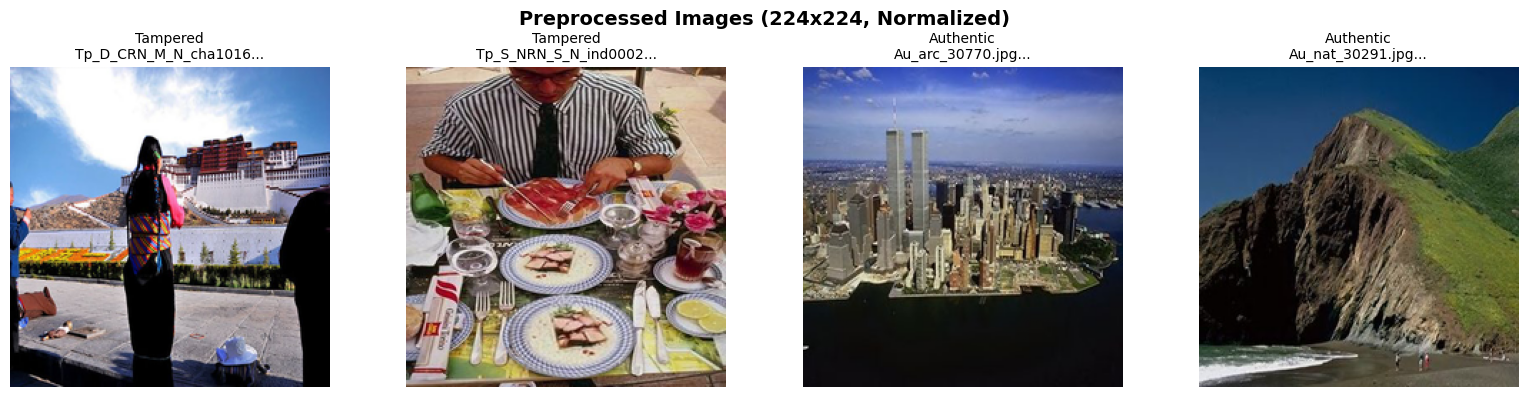

In [55]:
# Show 4 random samples
num_samples = 4
sample_indices = np.random.choice(len(X), num_samples, replace=False)

fig, axes = plt.subplots(1, num_samples, figsize=(16, 4))
fig.suptitle('Preprocessed Images (224x224, Normalized)', fontsize=14, fontweight='bold')

for i, idx in enumerate(sample_indices):
    axes[i].imshow(X[idx])
    label = 'Authentic' if y[idx] == 0 else 'Tampered'
    axes[i].set_title(f'{label}\n{filenames[idx][:20]}...', fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [90]:
OUTPUT_DIR = Path('preprocessed_casia')
OUTPUT_DIR.mkdir(exist_ok=True)

# Save preprocessed images
np.savez_compressed(
    OUTPUT_DIR / 'casia_preprocessed.npz',
    images=X,
    labels=y,
    filenames=filenames
)

print(f"✓ Saved to {OUTPUT_DIR}/casia_preprocessed.npz")

✓ Saved to preprocessed_casia/casia_preprocessed.npz


# Audio Dataset

ASVspoof 2019 Logical Access (LA) from [ASVspoof 2019](https://datashare.ed.ac.uk/handle/10283/3336)

Audio: FLAC format
Labels: bonafide (genuine) vs spoof (fake)

In [61]:
import numpy as np
import pandas as pd
from pathlib import Path
import librosa
import librosa.display
import soundfile as sf 
from tqdm import tqdm
import matplotlib.pyplot as plt

print("✓ Packages imported")

✓ Packages imported


In [82]:
# Dataset paths
BASE_DIR = Path('/Users/jadelynminneke/Desktop/NTU/Y2S2/IS460 ML/Project/Datasets/Dataset_Audio/LA')
TRAIN_AUDIO_DIR = BASE_DIR / 'ASVspoof2019_LA_train' / 'flac'
DEV_AUDIO_DIR = BASE_DIR / 'ASVspoof2019_LA_dev' / 'flac'
PROTOCOL_DIR = BASE_DIR / 'ASVspoof2019_LA_cm_protocols' 

# Protocol files
TRAIN_PROTOCOL = PROTOCOL_DIR / 'ASVspoof2019.LA.cm.train.trn.txt'
DEV_PROTOCOL = PROTOCOL_DIR / 'ASVspoof2019.LA.cm.dev.trl.txt'

# Config
SAMPLE_RATE = 16000
TARGET_DURATION = 4.0
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512

print("Paths configured:")
print(f"  Sample rate: 16 kHz")
print(f"  Format: FLAC")

Paths configured:
  Sample rate: 16 kHz
  Format: FLAC


In [83]:
# Load protocol (labels)

def load_protocol(protocol_file):
    """
    Load protocol: SPEAKER_ID AUDIO_FILE_NAME - SYSTEM_ID KEY
    Returns: DataFrame with audio_file and label
    """
    data = []
    with open(protocol_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            data.append({
                'audio_file': parts[1],
                'system_id': parts[3],
                'label': 0 if parts[4] == 'bonafide' else 1,
                'label_name': parts[4]
            })
    return pd.DataFrame(data)

train_df = load_protocol(TRAIN_PROTOCOL)
dev_df = load_protocol(DEV_PROTOCOL)

print(f"\nTrain: {len(train_df)} samples")
print(f"Dev: {len(dev_df)} samples")
print(f"\nTrain distribution:")
print(train_df['label_name'].value_counts())
display(train_df.head())


Train: 25380 samples
Dev: 24844 samples

Train distribution:
label_name
spoof       22800
bonafide     2580
Name: count, dtype: int64


,audio_file,system_id,label,label_name
0,LA_T_1138215,-,0,bonafide
1,LA_T_1271820,-,0,bonafide
2,LA_T_1272637,-,0,bonafide
3,LA_T_1276960,-,0,bonafide
4,LA_T_1341447,-,0,bonafide


In [84]:
def preprocess_audio(audio_path, sr=16000, duration=4.0):
    """Load audio and extract mel-spectrogram"""
    try:
        # Load and pad/truncate
        audio, _ = librosa.load(audio_path, sr=sr, duration=duration)
        target_length = int(sr * duration)
        
        if len(audio) < target_length:
            audio = np.pad(audio, (0, target_length - len(audio)))
        else:
            audio = audio[:target_length]
        
        # Extract mel-spectrogram
        mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=N_MELS)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        return mel_spec_db
    except:
        return None

In [85]:
# Use train_df -> later can use dev_df for validate and tune model during training

features = []
labels = []
filenames = []

for idx, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Processing"):
    audio_path = TRAIN_AUDIO_DIR / f"{row['audio_file']}.flac"
    
    if audio_path.exists():
        feature = preprocess_audio(audio_path, SAMPLE_RATE, TARGET_DURATION)
        if feature is not None:
            features.append(feature)
            labels.append(row['label'])
            filenames.append(row['audio_file'])

X_train = np.array(features)
y_train = np.array(labels)
files_train = np.array(filenames)

print(f"\n✓ Training set processed")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")

Processing: 100%|████████████████████████| 25380/25380 [01:54<00:00, 220.88it/s]



✓ Training set processed
  X_train: (25380, 128, 126)
  y_train: (25380,)


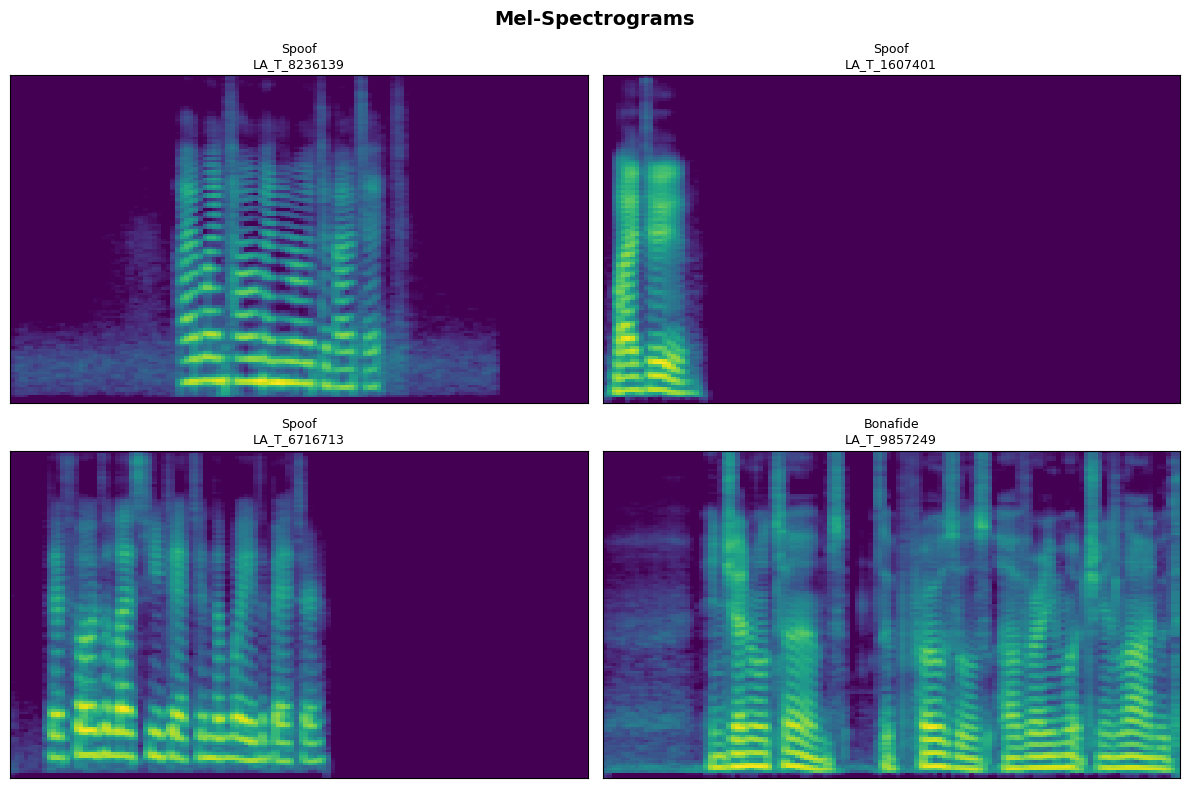

In [91]:
# Show 4 samples
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Mel-Spectrograms', fontsize=14, fontweight='bold')

sample_idx = np.random.choice(len(X_train), 4, replace=False)

for i, idx in enumerate(sample_idx):
    ax = axes[i//2, i%2]
    librosa.display.specshow(X_train[idx], sr=SAMPLE_RATE, ax=ax, cmap='viridis')
    label = 'Bonafide' if y_train[idx] == 0 else 'Spoof'
    ax.set_title(f'{label}\n{files_train[idx][:25]}', fontsize=9)

plt.tight_layout()
plt.show()

## Mel-Spectograms
- X-axis: time --> frequency components
- Y-axis: frequency --> temporal variations
- Colours: Energy/ amplitude in dB (dark purple = low energy; yellow/green = high energy) --> speech energy

*alt, we can try to use LFCC/CQCC (Linear/ Constant Q Cepstral Coefficients) which are usually used for spoofing detection (but more complicated)

In [89]:
OUTPUT_DIR = Path('preprocessed_asvspoof2019')
OUTPUT_DIR.mkdir(exist_ok=True)

np.savez_compressed(
    OUTPUT_DIR / 'asvspoof_train.npz',
    features=X,
    labels=y,
    filenames=files_train
)

print(f"\n✓ Saved to {OUTPUT_DIR}/asvspoof_train.npz")
print(f"✓ DONE!")


✓ Saved to preprocessed_asvspoof2019/asvspoof_train.npz
✓ DONE!
